In [56]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt 
import plotly_express as px 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight


In [57]:
data = yf.download("AAPL", start='2020-01-01', end='2026-04-18')

[*********************100%***********************]  1 of 1 completed


In [58]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696609,72.455927,71.472431,71.629115,146322800
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [59]:
data.columns = data.columns.droplevel(1)

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1581 entries, 2020-01-02 to 2026-04-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1581 non-null   float64
 1   High    1581 non-null   float64
 2   Low     1581 non-null   float64
 3   Open    1581 non-null   float64
 4   Volume  1581 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.1 KB


In [61]:
# Calculating Price Change
data['Price_Change'] = data['Close'].diff()
data['pct_change'] = data['Close'].pct_change() * 100
data.dropna(inplace=True)
data.head(5)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change
Date,,,,,,,
2020-01-03,71.696609,72.455927,71.472431,71.629115,146322800,-0.703903,-0.972235
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200,0.571304,0.796836
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000,-0.339859,-0.470276
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,1.157066,1.608644
2020-01-09,74.637482,74.830322,73.810669,74.061360,170108400,1.552361,2.124045


In [62]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Price_Change', 'pct_change'], dtype='object', name='Price')

In [63]:
# Seprating Gain and loss
data["Gain"] = data["Price_Change"].clip(lower=0)
data["Loss"] = -data["Price_Change"].clip(upper=0)

In [64]:
# Rolling Average
data['Avg_Gain'] = data['Gain'].rolling(5).mean()
data['Avg_Loss'] = data['Loss'].rolling(5).mean()

In [65]:
# Moving Average
data['MA_10'] = data['Close'].rolling(10).mean()
data['MA_50'] = data['Close'].rolling(50).mean()
data['MA_20'] = data['Close'].rolling(20).mean()
data['MA_100'] = data['Close'].rolling(100).mean()

data['MA_ratio'] = data['MA_10'] / data['MA_50']

# Volatility
data['Volatility'] = data['Close'].rolling(10).std()

In [66]:
data['Momentum'] = data['Close'] - data['Close'].shift(5)
data['Momentum_10'] = data['Close'] - data['Close'].shift(10)
data['ROC'] = data['Close'].pct_change(periods=10)
data['EMA_10'] = data['Close'].ewm(span=10).mean()

In [67]:
data['BB_Middle'] = data['Close'].rolling(20).mean()
data['BB_Std'] = data['Close'].rolling(20).std()

data['BB_Upper'] = data['BB_Middle'] + 2 * data['BB_Std']
data['BB_Lower'] = data['BB_Middle'] - 2 * data['BB_Std']

data['BB_Width'] = data['BB_Upper'] - data['BB_Lower']

In [68]:
ema12 = data['Close'].ewm(span=12).mean()
ema26 = data['Close'].ewm(span=26).mean()
data['MACD'] = ema12 - ema26

In [69]:
data['Volume_MA_10'] = data['Volume'].rolling(10).mean()
data['Volume_Ratio'] = data['Volume'] / data['Volume_MA_10']

In [70]:
data['Volume_Change'] = data['Volume'].pct_change()

In [71]:
# Relative Strength
data['RS'] = data['Avg_Gain'] / data['Avg_Loss']

In [72]:
# RSI 
data['RSI'] = 100 - (100/(1 + data['RS']))

In [73]:
data['RSI_Lag1'] = data['RSI'].shift(1)
data['RSI_Lag2'] = data['RSI'].shift(2)

data['Return_Lag1'] = data['pct_change'].shift(1)
data['Return_Lag2'] = data['pct_change'].shift(2)

In [74]:
# Signal
data["Signal"] = "HOLD"
data.loc[(data["RSI"] < 30) & (data["RSI"].shift(1) >= 30), "Signal"] = "BUY"
data.loc[(data["RSI"] > 70) & (data["RSI"].shift(1) <= 70), "Signal"] = "SELL"

In [75]:
data.dropna(inplace=True)

In [76]:
data.head(21)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,Volume_MA_10,Volume_Ratio,Volume_Change,RS,RSI,RSI_Lag1,RSI_Lag2,Return_Lag1,Return_Lag2,Signal
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-27,77.071686,77.217055,75.855443,76.594401,112945200,0.334335,0.435688,0.334335,-0.000000,0.460806,...,129727200.0,0.870636,-0.100196,2.094722,67.686922,56.108003,78.550176,-0.677347,0.643823,HOLD
2020-05-28,77.105606,78.363040,76.470834,76.747029,133560800,0.033920,0.044011,0.033920,-0.000000,0.172499,...,123021040.0,1.085674,0.182527,0.784142,43.950657,67.686922,56.108003,0.435688,-0.677347,HOLD
2020-05-29,77.030495,77.808211,76.674343,77.347881,153532400,-0.075111,-0.097414,0.000000,0.075111,0.172499,...,122481360.0,1.253516,0.149532,1.441253,59.037428,43.950657,67.686922,0.044011,0.435688,HOLD
2020-06-01,77.977829,78.098969,76.853646,76.984479,80791200,0.947334,1.229817,0.947334,-0.000000,0.263118,...,113925640.0,0.709157,-0.473784,2.198386,68.734230,59.037428,43.950657,-0.097414,0.044011,HOLD
2020-06-02,78.338814,78.363043,77.270358,77.711309,87642800,0.360985,0.462933,0.360985,-0.000000,0.335315,...,109172080.0,0.802795,0.084806,22.321178,95.712052,68.734230,59.037428,1.229817,-0.097414,SELL
2020-06-03,78.770065,79.031732,78.086834,78.658619,104491200,0.431252,0.550495,0.431252,-0.000000,0.354698,...,109448240.0,0.954709,0.192239,23.611478,95.936855,95.712052,68.734230,0.462933,1.229817,HOLD
2020-06-04,78.091675,78.891196,77.718562,78.593196,87560400,-0.678391,-0.861229,0.000000,0.678391,0.347914,...,107053800.0,0.817910,-0.162031,2.308648,69.776174,95.936855,95.712052,0.550495,0.462933,HOLD
2020-06-05,80.315826,80.376396,78.312173,78.341246,137250400,2.224152,2.848129,2.224152,-0.000000,0.792744,...,110509960.0,1.241973,0.567494,5.842833,85.386169,69.776174,95.936855,-0.861229,0.550495,SELL
2020-06-08,80.790688,80.824610,79.303092,80.012971,95654400,0.474861,0.591242,0.474861,-0.000000,0.698250,...,111895080.0,0.854858,-0.303067,5.146371,83.730236,85.386169,69.776174,2.848129,-0.861229,HOLD


In [77]:
data.isnull().sum()

Price
Close            0
High             0
Low              0
Open             0
Volume           0
Price_Change     0
pct_change       0
Gain             0
Loss             0
Avg_Gain         0
Avg_Loss         0
MA_10            0
MA_50            0
MA_20            0
MA_100           0
MA_ratio         0
Volatility       0
Momentum         0
Momentum_10      0
ROC              0
EMA_10           0
BB_Middle        0
BB_Std           0
BB_Upper         0
BB_Lower         0
BB_Width         0
MACD             0
Volume_MA_10     0
Volume_Ratio     0
Volume_Change    0
RS               0
RSI              0
RSI_Lag1         0
RSI_Lag2         0
Return_Lag1      0
Return_Lag2      0
Signal           0
dtype: int64

In [78]:
data['Future_Return'] = (data['Close'].shift(-3) - data['Close']) / data['Close']

data['Target'] = np.where(data['Future_Return'] > 0.02, "BUY",
                   np.where(data['Future_Return'] < -0.025, "SELL", "HOLD"))

In [79]:
data = data[data['Target'] != 'HOLD']

In [80]:
le = LabelEncoder()
Y = le.fit_transform(data["Target"])

In [81]:
# features = ["RSI", "Avg_Gain", "Avg_Loss", "Price_Change", "pct_change","Volatility","MA_10","MA_50","Volume_Change","MACD","EMA_10","Momentum"]
features = ["BB_Width","MA_ratio","Volatility","MA_10","MA_100","MACD","RSI_Lag2","Return_Lag1","Volume_Ratio","Return_Lag2","Volume_Change","MA_50","Avg_Gain"]
X = data[features]
Y = data["Target"]

In [82]:
# # Train test Split 
# split = int(len(data)*0.8)

# X_train = X[:split]
# X_test = X[split:]

# Y_train = Y[:split]
# Y_test = Y[split:]

In [83]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

In [84]:

train_index = X_train.index
test_index = X_test.index

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = pd.DataFrame(X_train, index=train_index, columns=features)
X_test = pd.DataFrame(X_test, index=test_index, columns=features)

In [85]:

classes = np.unique(Y_train)
weights = compute_class_weight('balanced', classes=classes, y=Y_train)

class_weights = dict(zip(classes, weights))
print(class_weights)

{'BUY': np.float64(0.7953846153846154), 'SELL': np.float64(1.3463541666666667)}


In [86]:
# LogisticRegression 
model_lr = LogisticRegression()
model_lr.fit(X_train,Y_train)

# Prediction
y_pred_lr = model_lr.predict(X_test)

# Accuracy Check
print('Accuracy :', accuracy_score(Y_test,y_pred_lr))
print('classification_report:',classification_report(Y_test,y_pred_lr))

result = pd.DataFrame({
    'Actual': Y_test,
    'Prediction': y_pred_lr
})
result.head()

Accuracy : 0.49514563106796117
classification_report:               precision    recall  f1-score   support

         BUY       0.61      0.53      0.57        64
        SELL       0.36      0.44      0.40        39

    accuracy                           0.50       103
   macro avg       0.48      0.48      0.48       103
weighted avg       0.51      0.50      0.50       103



,Actual,Prediction
Date,,
2025-03-25,SELL,BUY
2025-03-28,BUY,BUY
2025-03-31,SELL,BUY
2025-04-01,SELL,BUY
2025-04-02,SELL,BUY


In [87]:
# RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,Y_train)

#Prediction
y_pred_rf = model_rf.predict(X_test)

#Accuracy check
print('accuracy_score :', accuracy_score(Y_test,y_pred_rf))
print('classification_report:',classification_report(Y_test,y_pred_rf))


#Prediction check
result_rf = pd.DataFrame({
    'Actual':Y_test,
    'Predicted':y_pred_rf
})
result_rf.head()

accuracy_score : 0.49514563106796117
classification_report:               precision    recall  f1-score   support

         BUY       0.63      0.45      0.53        64
        SELL       0.39      0.56      0.46        39

    accuracy                           0.50       103
   macro avg       0.51      0.51      0.49       103
weighted avg       0.54      0.50      0.50       103



,Actual,Predicted
Date,,
2025-03-25,SELL,BUY
2025-03-28,BUY,BUY
2025-03-31,SELL,BUY
2025-04-01,SELL,BUY
2025-04-02,SELL,BUY


In [88]:
# XGBClassifier
le = LabelEncoder()
Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)
model_XG = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
)

model_XG.fit(X_train,Y_train)

y_pred_xg = model_XG.predict(X_test)

print('Accuracy :',accuracy_score(Y_test,y_pred_xg))
print('classification_report:',classification_report(Y_test,y_pred_xg))


result_xg = pd.DataFrame({
    'Actual':Y_test,
    'Prediction':y_pred_xg
})
result_xg.head()


Accuracy : 0.5145631067961165
classification_report:               precision    recall  f1-score   support

           0       0.62      0.55      0.58        64
           1       0.38      0.46      0.42        39

    accuracy                           0.51       103
   macro avg       0.50      0.50      0.50       103
weighted avg       0.53      0.51      0.52       103



,Actual,Prediction
0,1,0
1,0,0
2,1,0
3,1,0
4,1,0


In [89]:
print("Train:", model_XG.score(X_train, Y_train))
print("Test:", model_XG.score(X_test, Y_test))

Train: 1.0
Test: 0.5145631067961165


In [90]:
data.head()

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,Volume_Change,RS,RSI,RSI_Lag1,RSI_Lag2,Return_Lag1,Return_Lag2,Signal,Future_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-29,77.030495,77.808211,76.674343,77.347881,153532400,-0.075111,-0.097414,0.000000,0.075111,0.172499,...,0.149532,1.441253,59.037428,43.950657,67.686922,0.044011,0.435688,HOLD,0.022583,BUY
2020-06-02,78.338814,78.363043,77.270358,77.711309,87642800,0.360985,0.462933,0.360985,-0.000000,0.335315,...,0.084806,22.321178,95.712052,68.734230,59.037428,1.229817,-0.097414,SELL,0.025237,BUY
2020-06-03,78.770065,79.031732,78.086834,78.658619,104491200,0.431252,0.550495,0.431252,-0.000000,0.354698,...,0.192239,23.611478,95.936855,95.712052,68.734230,0.462933,1.229817,HOLD,0.025652,BUY
2020-06-04,78.091675,78.891196,77.718562,78.593196,87560400,-0.678391,-0.861229,0.000000,0.678391,0.347914,...,-0.162031,2.308648,69.776174,95.936855,95.712052,0.550495,0.462933,HOLD,0.067232,BUY
2020-06-05,80.315826,80.376396,78.312173,78.341246,137250400,2.224152,2.848129,2.224152,-0.000000,0.792744,...,0.567494,5.842833,85.386169,69.776174,95.936855,-0.861229,0.550495,SELL,0.064374,BUY


In [91]:
Y_test = pd.Series(Y_test, index=X_test.index)
X_test = pd.DataFrame(X_test, index=Y_test.index)

In [92]:
y_pred_final = y_pred_xg
y_pred_final = le.inverse_transform(y_pred_final)

data.loc[X_test.index, 'ML_Signal'] = y_pred_final

In [93]:
def final_signal(row):
    if row['Signal'] == 'BUY' and row['ML_Signal'] == 'BUY':
        return 'STRONG BUY'
    
    elif row['Signal'] == 'SELL' and row['ML_Signal'] == 'SELL':
        return 'STRONG SELL'
    
    elif row['ML_Signal'] == 'BUY':
        return 'WEAK BUY'
    
    elif row['ML_Signal'] == 'SELL':
        return 'WEAK SELL'
    
    else:
        return 'HOLD'
    
data['Final_Signal'] = data.apply(final_signal, axis = 1)

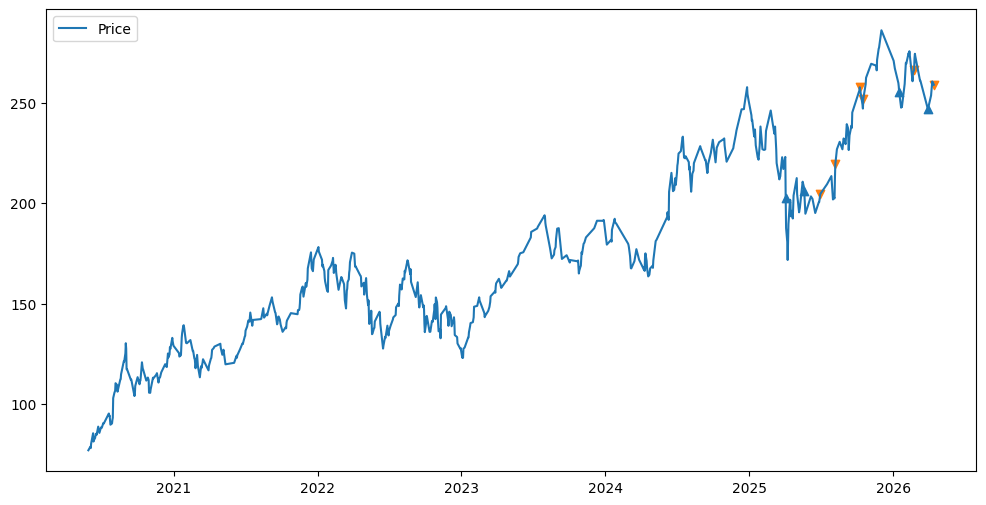

In [94]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='Price')

plt.scatter(buy.index, buy['Close'], marker='^')
plt.scatter(sell.index, sell['Close'], marker='v')

plt.legend()
plt.show()

In [95]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

fig = px.line(data, x=data.index, y='Close', title='Trading Signals')
fig.add_scatter(x=buy.index, y=buy['Close'], mode='markers', 
                marker=dict(symbol='triangle-up', size=10, color='green'), 
                name='STRONG BUY')
fig.add_scatter(x=sell.index, y=sell['Close'], mode='markers', 
                marker=dict(symbol='triangle-down', size=10, color='red'), 
                name='STRONG SELL')
fig.show()


In [96]:
latest = data.iloc[-1]

print("Price:", latest['Close'])
print("RSI Signal:", latest['Signal'])
print("ML Signal:", latest['ML_Signal'])
print("Final Signal:", latest['Final_Signal'])

Price: 258.8299865722656
RSI Signal: SELL
ML Signal: SELL
Final Signal: STRONG SELL


In [97]:
#confidance score
confidence = 0

if latest['Signal'] == latest['ML_Signal']:
    confidence = 2
elif latest['ML_Signal'] != 'HOLD':
    confidence = 1
else:
    confidence = 0

print("Confidence:", confidence)

Confidence: 2


In [98]:
# Decision Sytem 
if latest['Final_Signal'] == 'STRONG BUY':
    print("ENTER TRADE")
elif latest['Final_Signal'] == 'STRONG SELL':
    print("EXIT")
else:
    print("WAIT")

EXIT


In [99]:
## Variables
capital = 10000
position = 0
buy_price = 0

stop_loss = 0.03
take_profit = 0.06

trades = []

for i in range(len(data)):

    signal = data['Final_Signal'].iloc[i]
    price = data['Close'].iloc[i]

    #  Trend filter
    trend = "UP" if data['MA_50'].iloc[i] > data['MA_100'].iloc[i] else "DOWN"

    #  BUY 
    if signal in ['STRONG BUY', 'WEAK BUY'] and position == 0 and trend == "UP":
        position = capital / price
        buy_price = price
        capital = 0
        trades.append(('BUY', price, data.index[i]))

    #  SELL 
    elif signal in ['STRONG SELL', 'WEAK SELL'] and position != 0:
        capital = position * price
        position = 0
        trades.append(('SELL', price, data.index[i]))

    # RISK MANAGEMENT 
    elif position != 0:

        # Stop Loss
        if price < buy_price * (1 - stop_loss):
            capital = position * price
            position = 0
            trades.append(('STOP LOSS', price, data.index[i]))

        # Take Profit
        elif price > buy_price * (1 + take_profit):
            capital = position * price
            position = 0
            trades.append(('TAKE PROFIT', price, data.index[i]))


# IMPORTANT: close last position
if position != 0:
    capital = position * data['Close'].iloc[-1]
    trades.append(('FINAL SELL', data['Close'].iloc[-1], data.index[-1]))
    position = 0

In [100]:
# calculating  value 
if position != 0:
    capital = position * data['Close'].iloc[-1]

print("Final Capital:", capital)

Final Capital: 11694.487430536981


In [101]:
profit = capital - 10000
print("Profit:",profit)

Profit: 1694.4874305369813


In [102]:
# Buy pe
capital = capital * (1 - 0.001)

# Sell pe
capital = capital * (1 - 0.001)

In [103]:
print("Total Trades:", len(trades)//2)

Total Trades: 8


In [104]:
profits = []
wins = 0
total = 0

for i in range(0, len(trades)-1, 2):
    buy_price = trades[i][1]
    sell_price = trades[i+1][1]

    if sell_price > buy_price:
        wins += 1

    total += 1

print("Win Rate:", wins/total if total > 0 else 0)

Win Rate: 0.625


In [105]:
returns = (capital - 10000) / 10000
print("Return %:", returns * 100)

Return %: 16.711101501633387


In [106]:
data.to_json("dashboard.json", orient="records")

In [107]:
data.to_csv("final_output.csv")

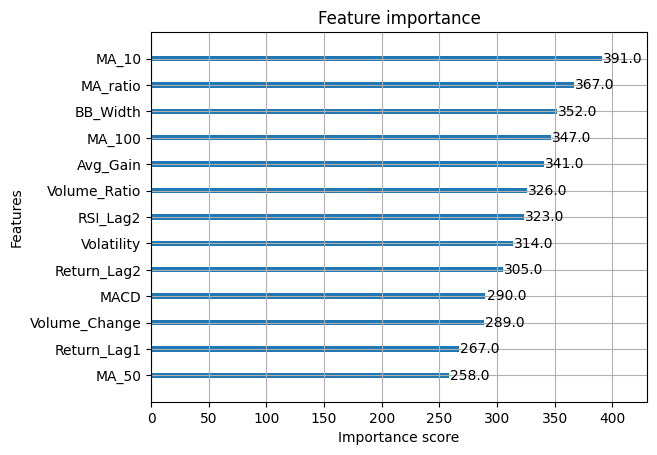

In [108]:
plot_importance(model_XG)
plt.show()